# Notebook 09 — Visualizations & Insights

This notebook focuses on generating meaningful visual insights from the processed dataset of construction delay factors.

Since the dataset is survey-based, the goal is to:
- Visualize the distribution of delay factors  
- Identify patterns and relationships  
- Highlight the most critical contributors to construction delays  
- Present insights in a clear, publication-ready format  

These visualizations support decision-making and help stakeholders understand the key drivers of delays in construction projects.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [43]:
df_scaled = pd.read_csv(r"C:\Users\olive\Desktop\My ML Material\CONSTRUCTION DELAY RISK PREDICTION SYSTEM\CDRPS\data\processed\df_scaled.csv")

df = df_scaled.copy()
print("Dataset loaded for Notebook 09.")
df.head()


Dataset loaded for Notebook 09.


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 8: Scope of work.3,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5
0,-1.719981,1,1,1,1,1,1,1,1,1,...,1,2,2,3,1,2,2,2,3,5
1,-1.695756,2,5,3,2,3,2,2,2,3,...,3,1,1,4,1,3,2,3,3,3
2,-1.671530,1,2,1,1,2,2,1,2,1,...,2,1,1,4,1,2,2,1,2,4
3,-1.647305,2,2,3,3,2,2,3,4,4,...,3,4,3,3,1,3,1,1,3,4
4,-1.623080,1,2,1,1,2,2,1,2,1,...,2,1,1,4,1,2,3,1,2,4


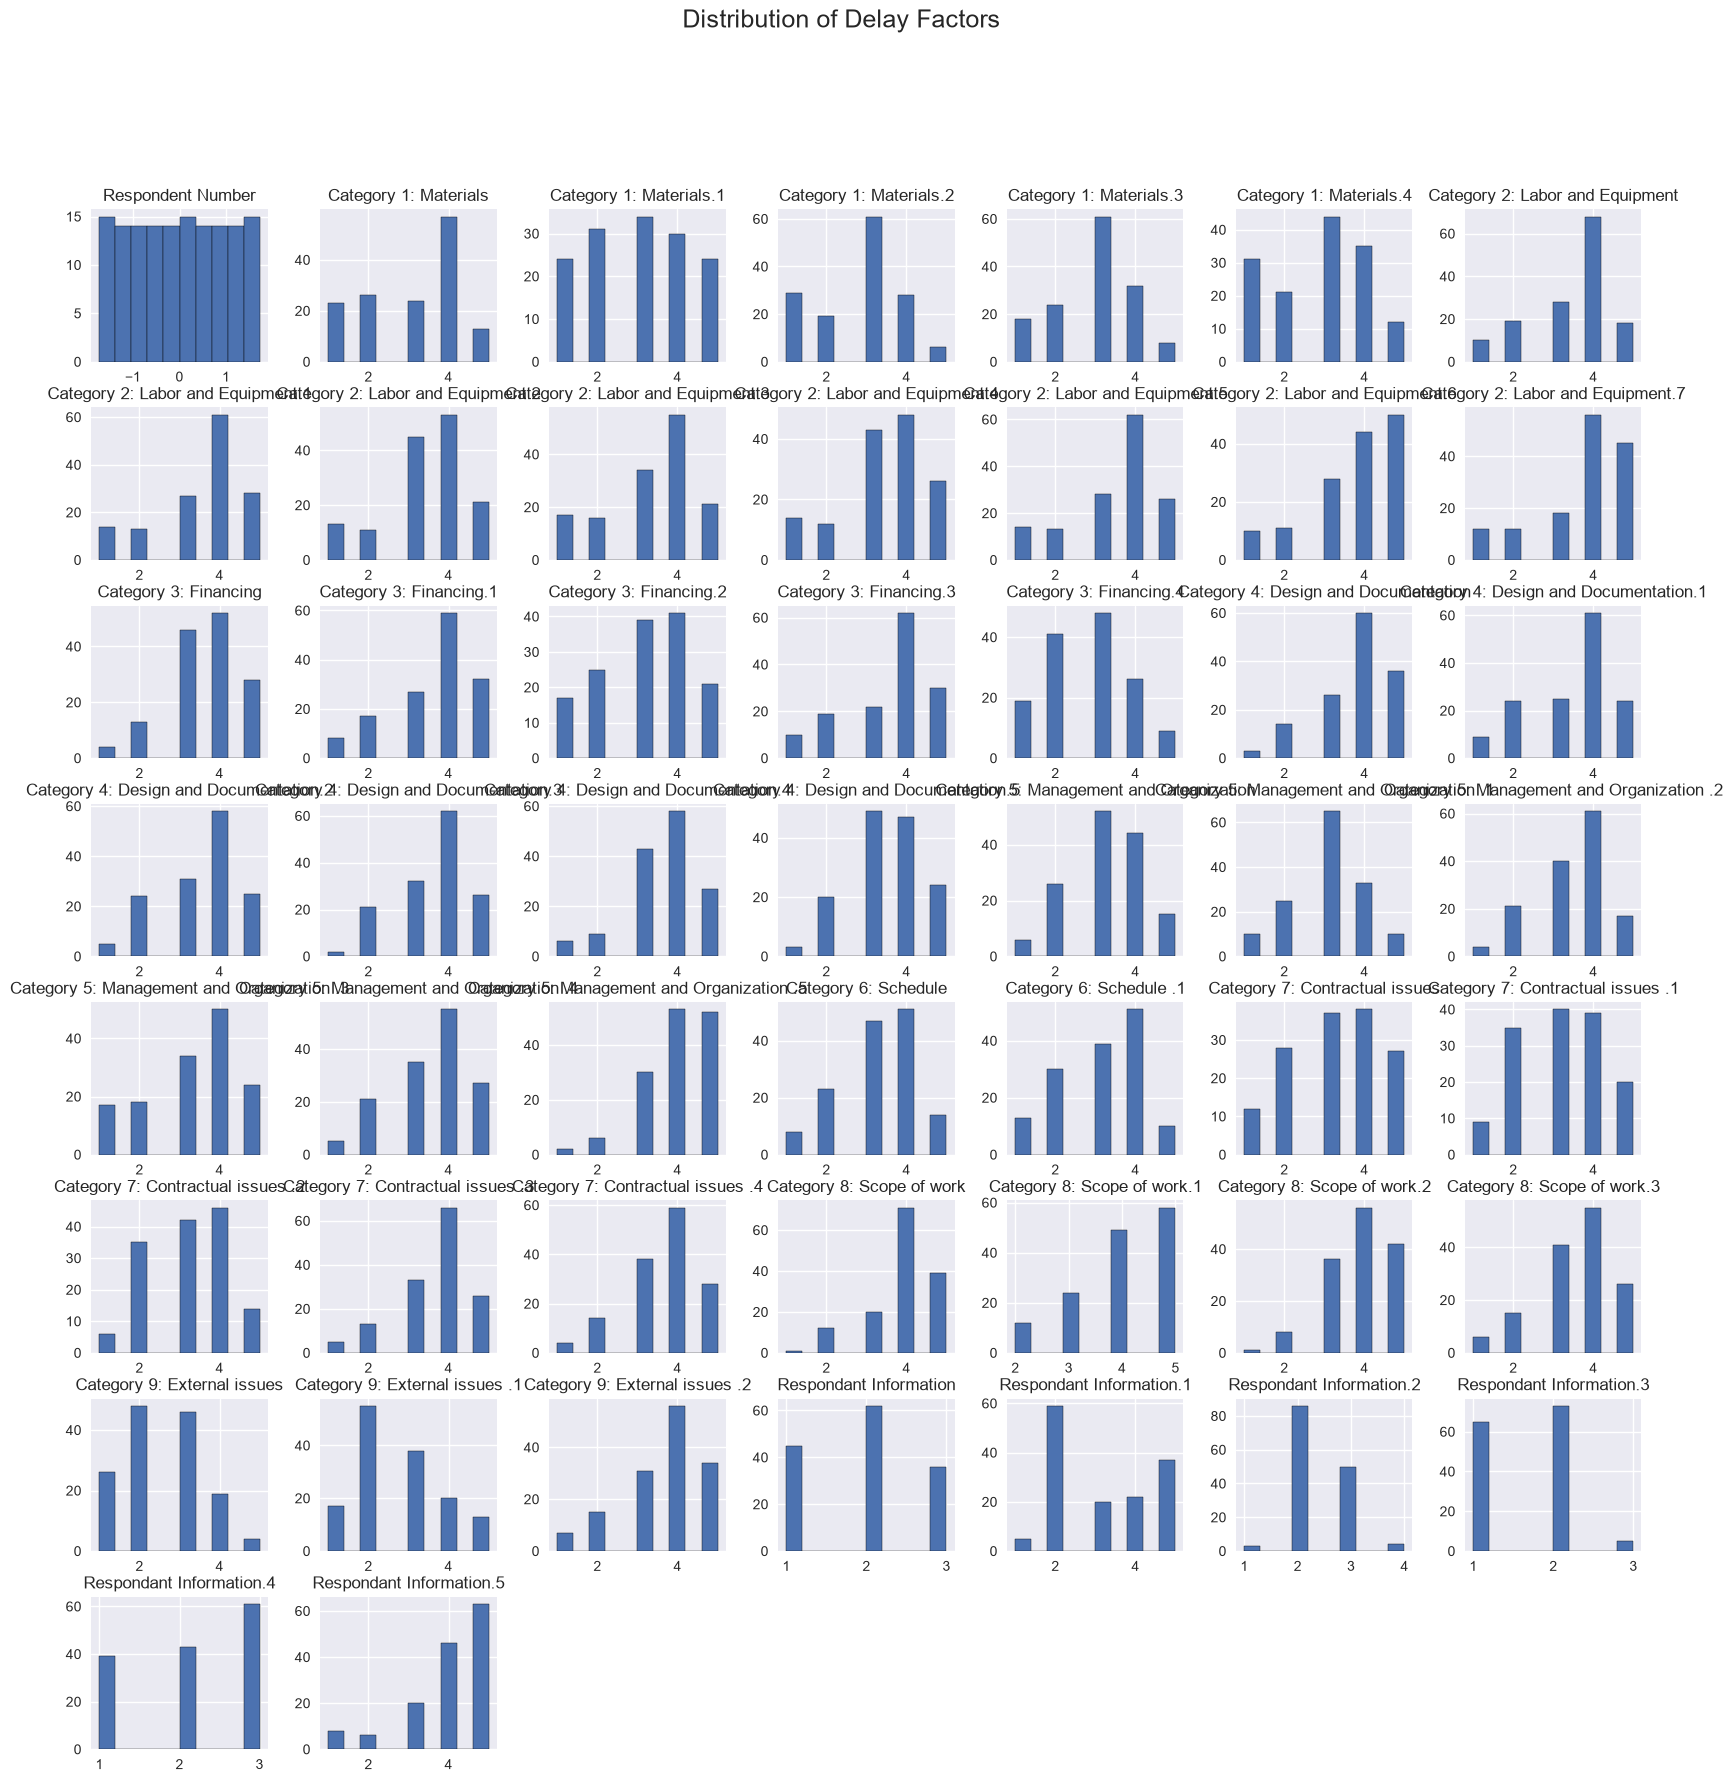

In [44]:
df.hist(figsize=(20, 20), bins=10, edgecolor='black')
plt.suptitle("Distribution of Delay Factors", fontsize=18)
plt.show()


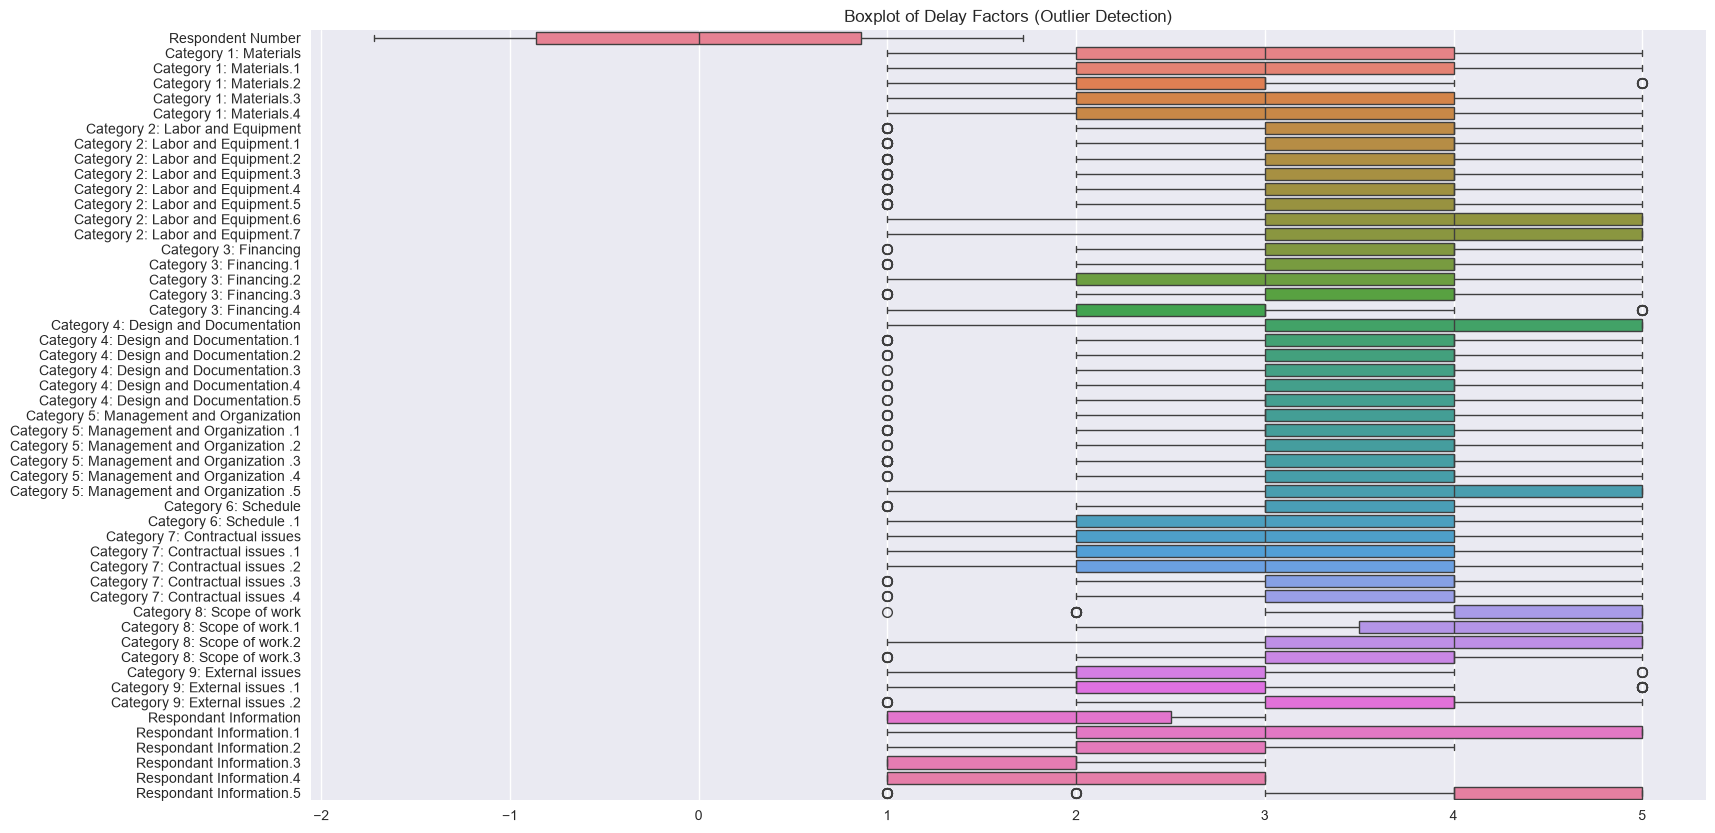

In [45]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=df, orient="h")
plt.title("Boxplot of Delay Factors (Outlier Detection)")
plt.show()


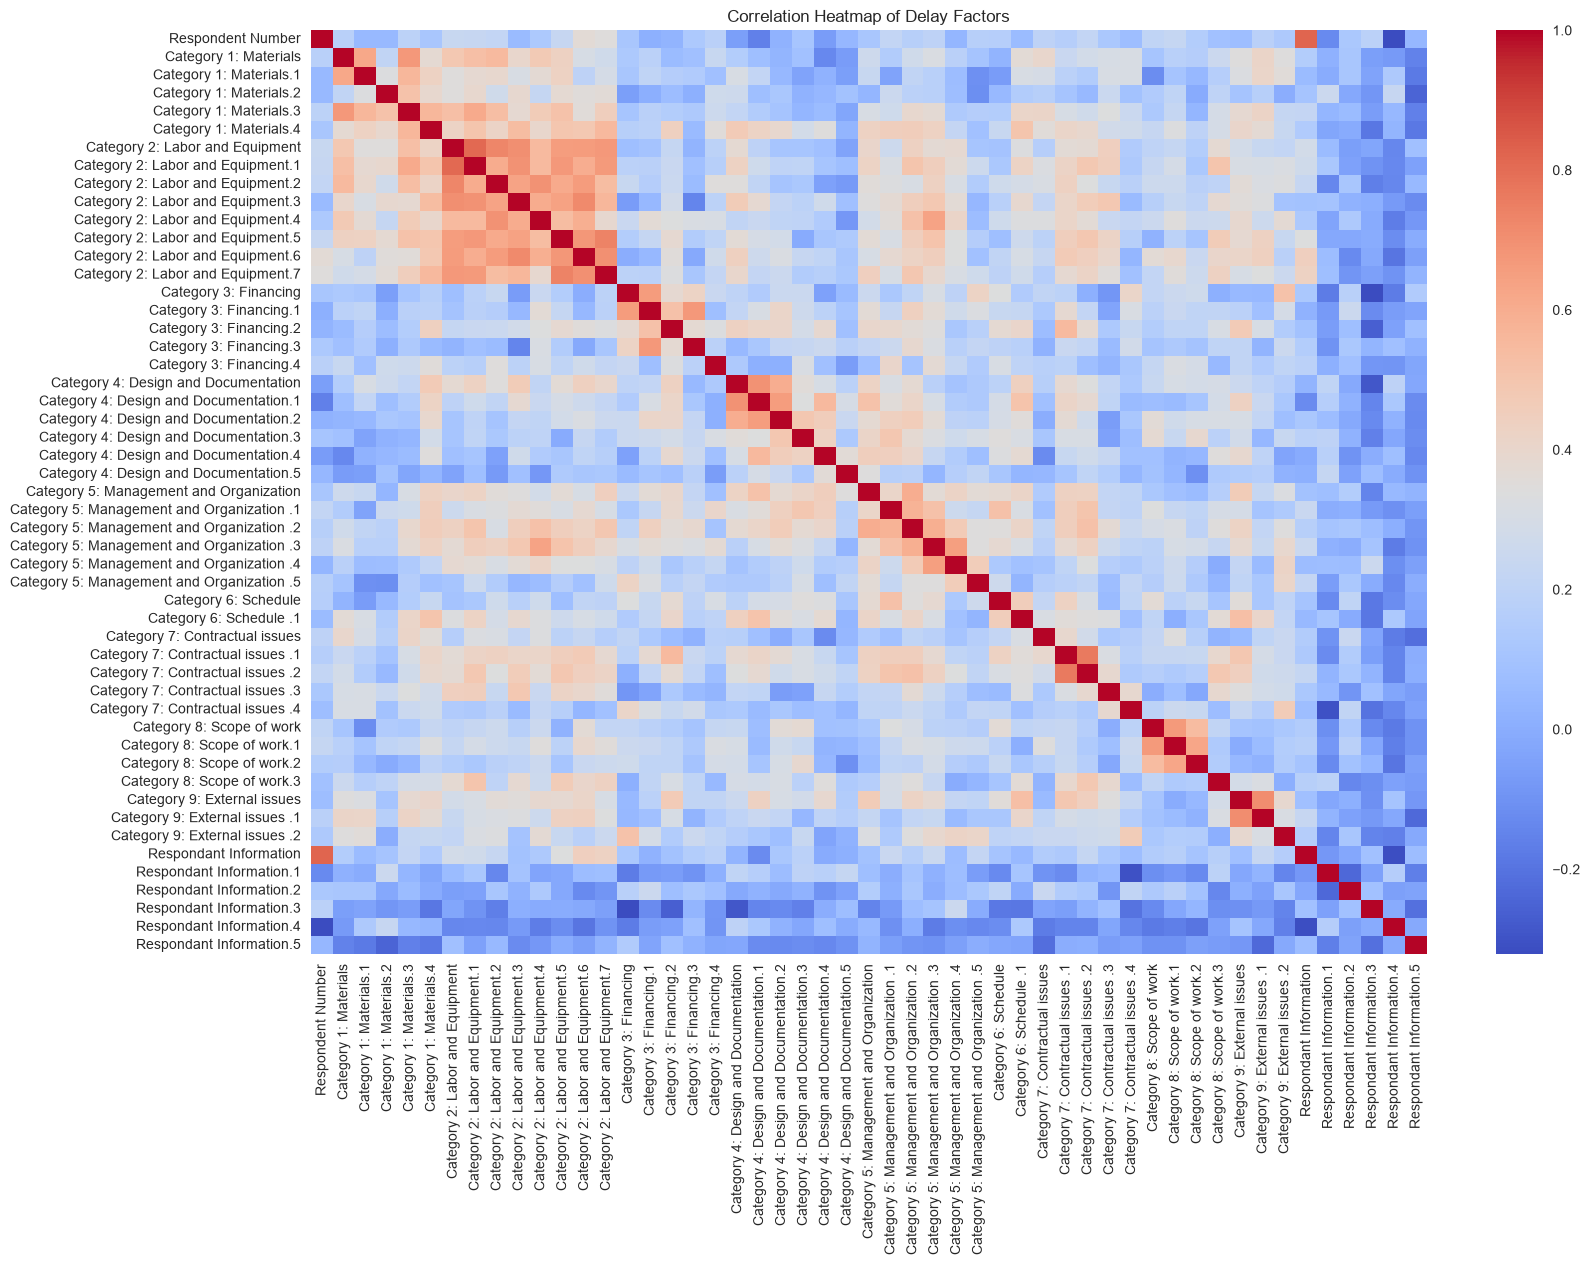

In [46]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Delay Factors")
plt.show()


In [47]:
corr_matrix = df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

top_corr = (
    upper_tri.stack()
    .sort_values(ascending=False)
    .head(10)
)

top_corr


Respondent Number                  Respondant Information               0.820849
Category 2: Labor and Equipment    Category 2: Labor and Equipment.1    0.814000
Category 7: Contractual issues .1  Category 7: Contractual issues .2    0.765447
Category 2: Labor and Equipment.5  Category 2: Labor and Equipment.7    0.737830
Category 2: Labor and Equipment    Category 2: Labor and Equipment.2    0.726518
Category 2: Labor and Equipment.3  Category 2: Labor and Equipment.6    0.720428
Category 9: External issues        Category 9: External issues .1       0.708905
Category 2: Labor and Equipment    Category 2: Labor and Equipment.3    0.701916
Category 2: Labor and Equipment.6  Category 2: Labor and Equipment.7    0.700521
Category 2: Labor and Equipment.1  Category 2: Labor and Equipment.3    0.694279
dtype: float64

In [48]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Select numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# 2. Impute missing values
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(numeric_df)

# 3. Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. PCA
pca = PCA(n_components=5)
pca_components = pca.fit_transform(X_scaled)

# 5. Loadings (optional but useful)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(5)],
    index=numeric_df.columns
)


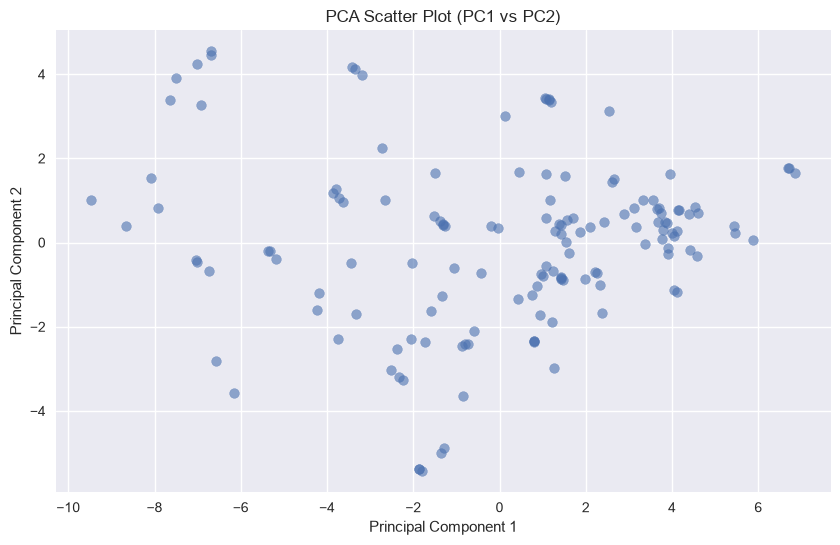

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot (PC1 vs PC2)")
plt.show()


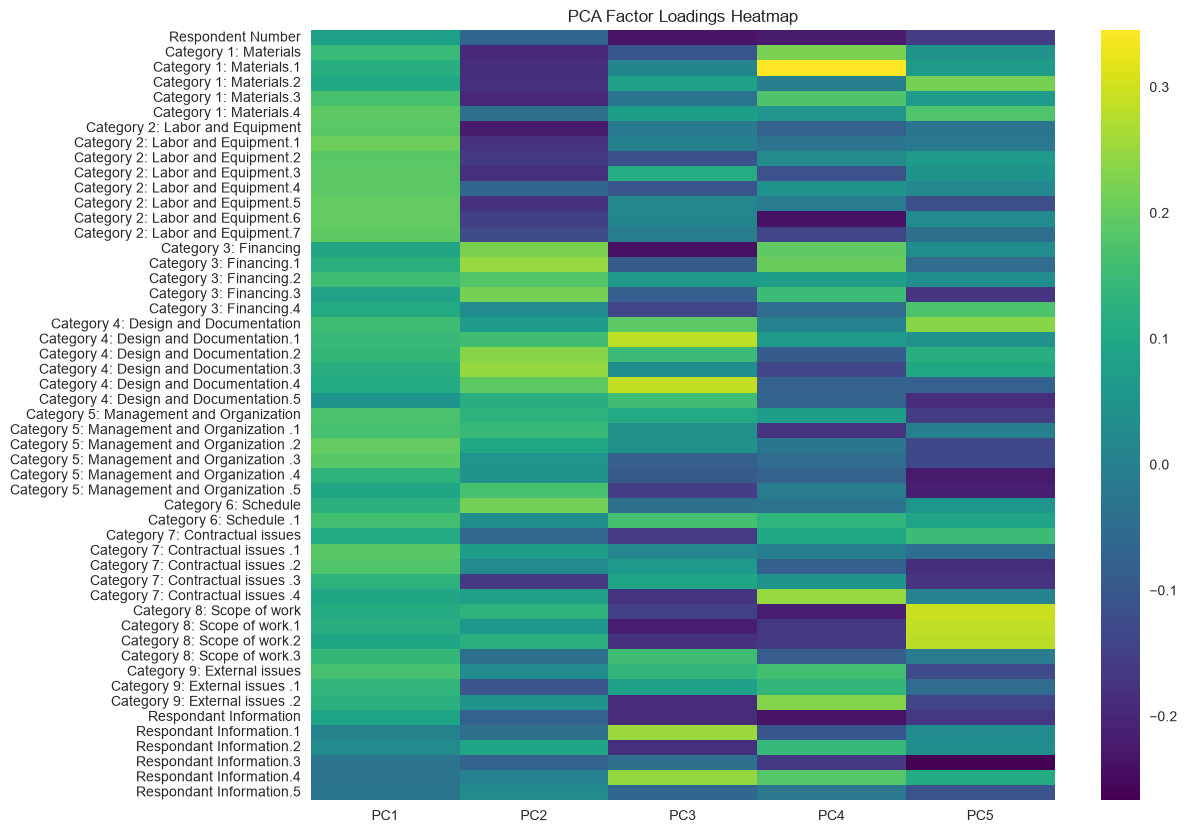

In [50]:
plt.figure(figsize=(12, 10))
sns.heatmap(loadings, cmap="viridis", annot=False)
plt.title("PCA Factor Loadings Heatmap")
plt.show()


In [51]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Select numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# 2. Impute missing values
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(numeric_df)

# 3. Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 5. Create df_clusters
df_clusters = df.copy()
df_clusters["Cluster"] = clusters


C:\Users\olive\AppData\Local\Temp\ipykernel_56068\1240912202.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clusters["Cluster"], palette="viridis")


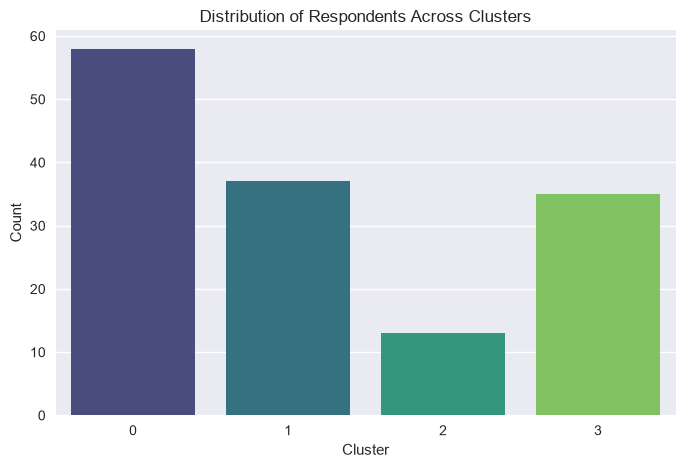

In [52]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df_clusters["Cluster"], palette="viridis")
plt.title("Distribution of Respondents Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


In [53]:
cluster_profiles = df_clusters.groupby("Cluster").mean()
cluster_profiles


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 8: Scope of work.3,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.099824,3.500000,3.655172,2.775862,3.310345,3.482759,3.948276,4.155172,3.862069,3.827586,...,4.017241,3.206897,3.275862,4.293103,2.034483,3.120690,2.482759,1.534483,2.120690,3.931034
1,-0.074639,3.054054,2.918919,2.486486,2.648649,1.945946,2.810811,2.756757,3.108108,2.810811,...,2.702703,2.000000,2.270270,3.486486,1.729730,2.675676,2.567568,1.837838,2.189189,3.972973
2,-0.935461,1.230769,1.461538,1.230769,1.230769,1.230769,1.769231,1.538462,1.307692,1.000000,...,3.000000,1.538462,1.769231,2.769231,1.307692,3.461538,2.153846,1.307692,2.384615,4.538462
3,0.260939,3.085714,2.542857,3.514286,3.171429,3.285714,3.942857,4.057143,3.742857,3.914286,...,3.914286,2.171429,2.542857,3.142857,2.228571,3.742857,2.114286,1.485714,2.085714,4.142857


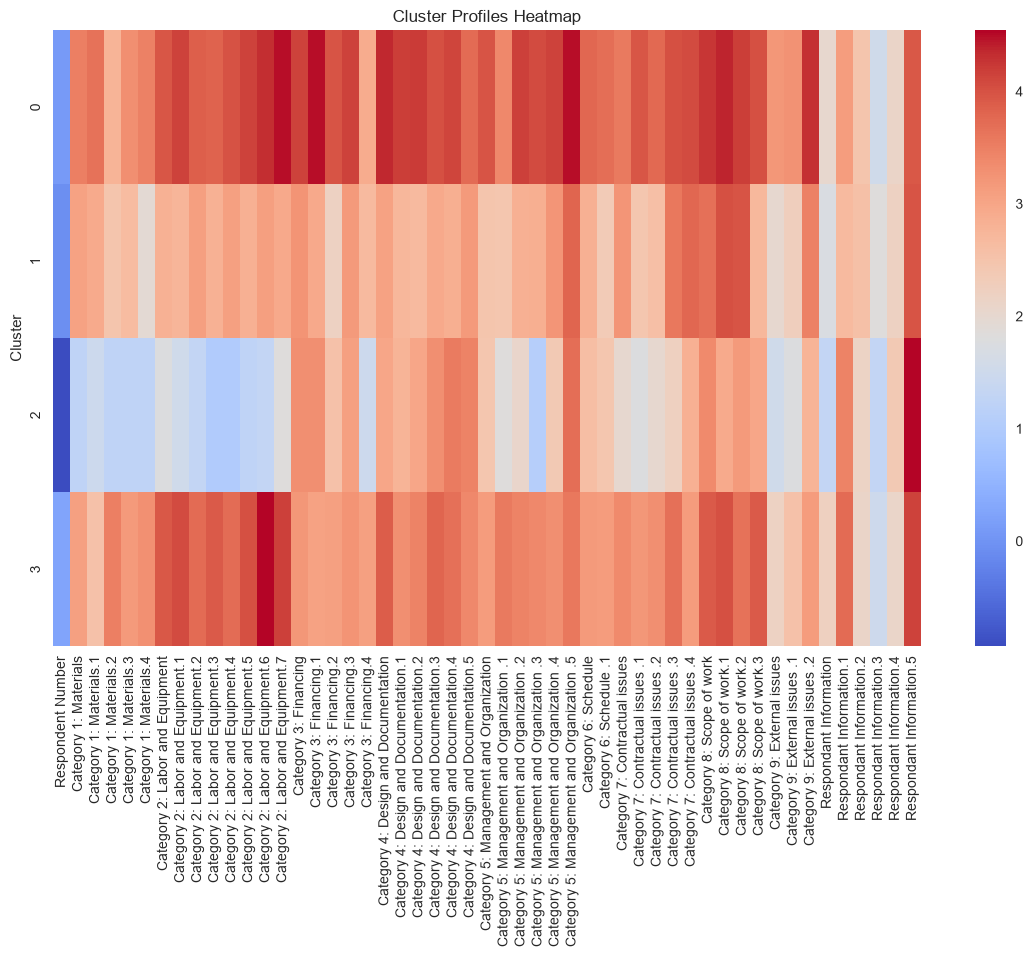

In [54]:
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles, cmap="coolwarm", annot=False)
plt.title("Cluster Profiles Heatmap")
plt.show()


In [55]:
# Recreate Delay Risk Index inside Notebook 09
df["Delay_Risk_Index"] = df.mean(axis=1)


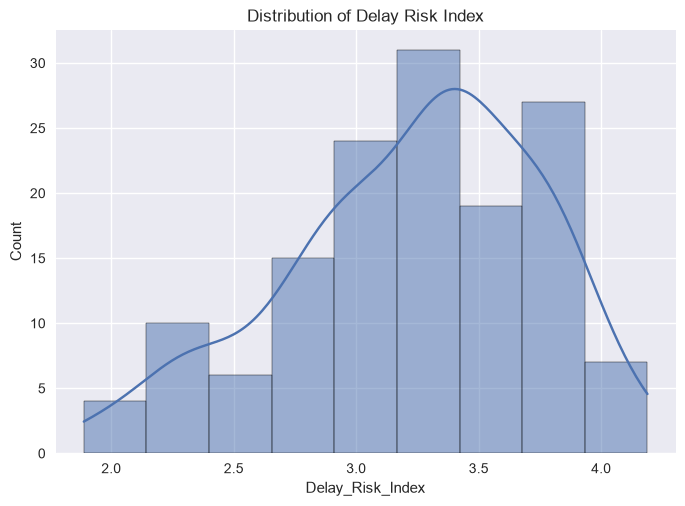

In [56]:
sns.histplot(df["Delay_Risk_Index"], kde=True)
plt.title("Distribution of Delay Risk Index")
plt.show()


In [57]:
df_sorted = df.sort_values("Delay_Risk_Index", ascending=False).head(20)
df_sorted


,Respondent Number,Category 1: Materials,Category 1: Materials.1,Category 1: Materials.2,Category 1: Materials.3,Category 1: Materials.4,Category 2: Labor and Equipment,Category 2: Labor and Equipment.1,Category 2: Labor and Equipment.2,Category 2: Labor and Equipment.3,...,Category 9: External issues,Category 9: External issues .1,Category 9: External issues .2,Respondant Information,Respondant Information.1,Respondant Information.2,Respondant Information.3,Respondant Information.4,Respondant Information.5,Delay_Risk_Index
138,1.623080,5,3,2,3,5,5,5,5,5,...,4,4,5,2,2,3,1,1,5,4.188688
66,-0.121125,5,3,2,3,5,5,5,5,5,...,4,4,5,2,2,3,1,2,5,4.174096
65,-0.145350,5,3,2,3,5,5,5,5,5,...,4,4,5,2,2,3,1,1,5,4.154013
51,-0.484502,5,4,4,5,2,5,5,5,4,...,4,4,4,2,4,2,1,3,3,3.990500
49,-0.532952,5,4,4,5,2,5,5,5,4,...,4,4,4,2,5,3,1,1,4,3.989550
16,-1.332379,5,3,2,4,4,5,5,5,5,...,5,5,5,1,3,2,2,1,2,3.954267
118,1.138579,4,5,3,5,5,4,4,4,3,...,4,4,4,3,5,3,1,3,5,3.943894
136,1.574630,4,5,4,3,4,4,4,4,4,...,4,3,4,2,5,2,2,2,3,3.932836
69,-0.048450,4,5,4,3,4,4,4,4,4,...,4,3,4,2,4,2,2,3,3,3.901011
76,0.121125,5,3,3,3,2,5,4,4,4,...,3,3,4,2,4,2,2,2,3,3.865120


C:\Users\olive\AppData\Local\Temp\ipykernel_56068\4201129830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


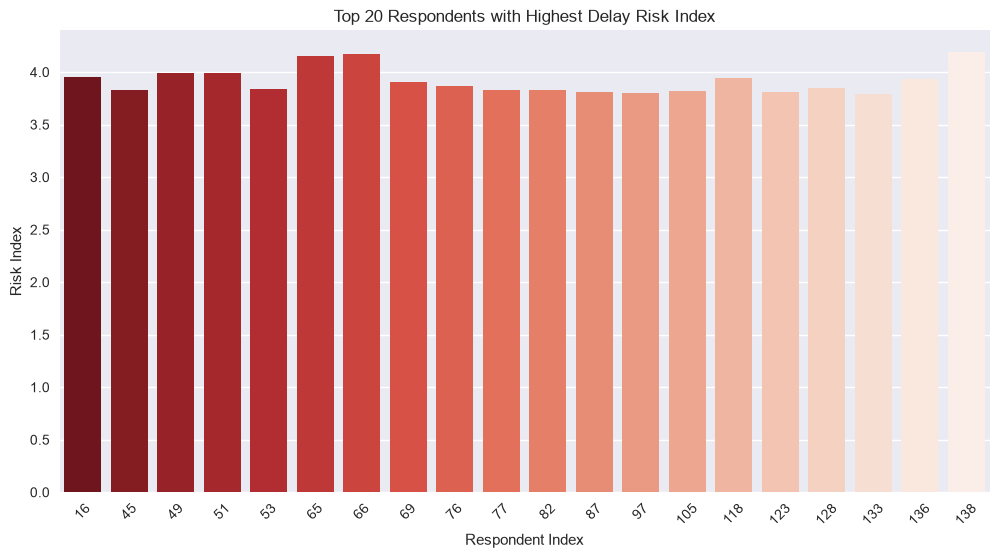

In [58]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=df_sorted.index,
    y=df_sorted["Delay_Risk_Index"],
    palette="Reds_r"
)
plt.title("Top 20 Respondents with Highest Delay Risk Index")
plt.xlabel("Respondent Index")
plt.ylabel("Risk Index")
plt.xticks(rotation=45)
plt.show()
